# Sử dụng CPU trích xuất

In [1]:
import os
import cv2
import numpy as np
import cupy as cp
import pandas as pd
from skimage.feature import local_binary_pattern
from tqdm import tqdm

def label_check(filename):
    filename = filename.lower()
    if 'fake' in filename:
        return 0
    elif 'real' in filename:
        return 1
    else:
        return -1


class ExtractFeature:
    def __init__(self, path_origin, path_real, path_fake, label_image_csv):
        self.path = path_origin
        self.path_real = path_real + '/'
        self.path_fake = path_fake + '/'
        self.label_image = pd.read_csv(label_image_csv, header=None)
        self.size_default = (240, 240)

  
        
    def fft_gpu(self, gray_image_resized):
        gray_gpu = cp.asarray(gray_image_resized)
        fft = cp.fft.fft2(gray_gpu)
        fft_shifted = cp.fft.fftshift(fft)
        magnitude_spectrum = cp.log1p(cp.abs(fft_shifted))
        return cp.asnumpy(magnitude_spectrum).flatten()
    def fft_cpu(self, gray_image_resized):
        fft_image = np.fft.fft2(gray_image_resized)
        fft_shifted = np.fft.fftshift(fft_image)

        magnitude_spectrum = np.log(1 + np.abs(fft_shifted))
        return magnitude_spectrum.flatten()        

    def lbp_cpu(self, gray_image_resized):
        lbp = local_binary_pattern(gray_image_resized, P=8, R=1, method='uniform')
        hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 10), density=True)
        return hist

    def extract_all(self):
        data_extract = []
        for filename in tqdm(self.label_image[0], desc="Trích đặc trưng"):
            label = label_check(filename)
            if label == -1:
                continue

            sub_path = self.path_fake if label == 0 else self.path_real
            full_path = os.path.join(self.path, sub_path, filename)
            full_path = self.path+full_path
            img_gray = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
            if img_gray is None:
                print(f"Không đọc được ảnh: {full_path}")
                continue

            img_resized = cv2.resize(img_gray, self.size_default, interpolation=cv2.INTER_AREA)

            #pre_process
            # Tách riêng từng phần để dễ kiểm soát GPU/CPU load
            fft_feat = self.fft_cpu(img_resized)
            lbp_feat = self.lbp_cpu(img_resized)

            features = np.concatenate([fft_feat, lbp_feat])
            features_with_label = np.append(features, label)
            data_extract.append(features_with_label)

        if not data_extract:
            print("Không có ảnh hợp lệ nào.")
            return pd.DataFrame()

        n_features = len(data_extract[0]) - 1
        columns = [f'f{i}' for i in range(n_features)] + ['label']
        return pd.DataFrame(data_extract, columns=columns)



In [ ]:
path = '/kaggle/input/data-img-fake-real'
path_real = '/real'
path_fake = '/fake'
labels = '/labels.csv'
ex = ExtractFeature(path,path_real,path_fake,path + labels)
df = ex.extract_all()

# sử dụng gpu

In [12]:
import os
import cv2
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from skimage.feature import local_binary_pattern, hog
from tqdm import tqdm


# === Hàm check nhãn từ tên file
def label_check(filename):
    filename = filename.lower()
    if 'fake' in filename:
        return 0
    elif 'real' in filename:
        return 1
    else:
        return -1

# === Hàm xử lý từng ảnh riêng biệt (sẽ chạy song song)
def process_single_image(full_path, label):
    try:
        img_gray = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
        if img_gray is None:
            print(f"Không đọc được ảnh: {full_path}")
            return None

        img_resized = cv2.resize(img_gray, (300, 300), interpolation=cv2.INTER_AREA)

        
        # === FFT
        fft_image = np.fft.fft2(img_resized)
        fft_shifted = np.fft.fftshift(fft_image)
        magnitude_spectrum = np.log1p(np.abs(fft_shifted)).flatten()

        # === LBP
        lbp = local_binary_pattern(img_resized, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 10), density=True)
        
        # === Combine all features
        features = np.concatenate([magnitude_spectrum, lbp_hist])
        features_with_label = np.append(features, label)
        return features_with_label

    except Exception as e:
        print(f"Lỗi ảnh {full_path}: {e}")
        return None

# === Class trích xuất đặc trưng
class ExtractFeature:
    def __init__(self, path_origin, path_real, path_fake, label_image_csv):
        self.path = path_origin
        self.path_real = path_real.strip('/')
        self.path_fake = path_fake.strip('/')
        self.label_image = pd.read_csv(label_image_csv, header=None)

    def extract_all(self, num_jobs=4):
        args_list = []
        for filename in self.label_image[0]:
            label = label_check(filename)
            if label == -1:
                continue
            sub_path = self.path_fake if label == 0 else self.path_real
            full_path = os.path.join(self.path, sub_path, filename)
            args_list.append((full_path, label))

        print(f"{num_jobs} CPU...")

        results = Parallel(n_jobs=num_jobs)(
            delayed(process_single_image)(path, label)
            for path, label in tqdm(args_list)
        )

        # Lọc bỏ kết quả None
        data_extract = [r for r in results if r is not None]

        if not data_extract:
            print("Không có ảnh hợp lệ.")
            return pd.DataFrame()

        n_features = len(data_extract[0]) - 1
        columns = [f'f{i}' for i in range(n_features)] + ['label']
        return pd.DataFrame(data_extract, columns=columns)


In [13]:
path = '/kaggle/input/data-img-fake-real'
path_real = '/real'
path_fake = '/fake'
labels = 'labels.csv'

ex = ExtractFeature(path, path_real, path_fake, os.path.join(path, labels))
df = ex.extract_all(num_jobs=4)
df.head()


4 CPU...


100%|██████████| 3417/3417 [01:10<00:00, 48.18it/s]


KeyboardInterrupt: 

In [ ]:
# df.to_csv('feature_raw_080.csv')

In [3]:
df.shape

(3417, 57610)

In [5]:
(df==0).sum().sum()

1711

# chia X,Y

In [14]:
X = df.drop('label', axis=1)
y = df['label']

In [ ]:
# y.to_csv('labels.csv')

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=512)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA với toàn bộ chiều
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Lấy tỉ lệ phương sai tích lũy
explained_var = np.cumsum(pca.explained_variance_ratio_)

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
plt.plot(explained_var, marker='o')
plt.xlabel('Số thành phần PCA')
plt.ylabel('Tổng phương sai giữ lại')
plt.title('Biểu đồ chọn số chiều PCA tốt nhất')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--')  # đường tham chiếu 95%
plt.show()
         

In [17]:
print(f"Tổng phương sai giữ lại: {sum(pca.explained_variance_ratio_)*100:.2f}%")
features_pca = pd.DataFrame(X_pca)

Tổng phương sai giữ lại: 61.23%


In [ ]:
# # import joblib

# joblib.dump(X_scaled, "scaler.pkl")
# joblib.dump(X_pca, "pca.pkl")

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


In [9]:
Xh_train, Xh_test, yh_train, yh_test = train_test_split(features_pca, y, test_size=0.3, random_state=42)

## Logistic Regression

              precision    recall  f1-score   support

         0.0       0.73      0.71      0.72       517
         1.0       0.71      0.73      0.72       509

    accuracy                           0.72      1026
   macro avg       0.72      0.72      0.72      1026
weighted avg       0.72      0.72      0.72      1026



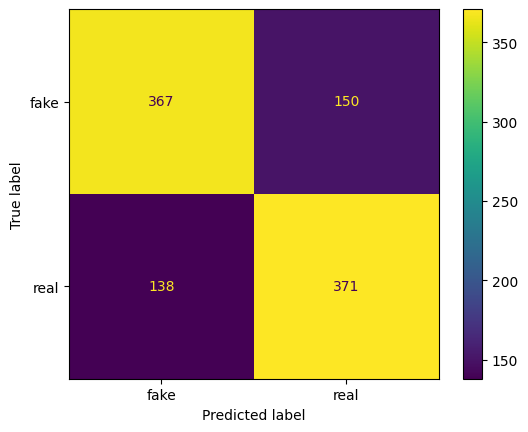

In [18]:
model = LogisticRegression(solver='newton-cholesky')
LogisticRegression()
model.fit(Xh_train,yh_train)
y_pred = model.predict(Xh_test)

print(classification_report(yh_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(yh_test,y_pred),display_labels=['fake','real']).plot();

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import numpy as np

# Khởi tạo mô hình và KFold
model = LogisticRegression(solver='newton-cholesky', max_iter=1000)
kf = KFold(n_splits=5, shuffle=True, random_state=42)


# Chuyển X, y sang mảng nếu cần
y_copy = y.copy()
X = features_pca.to_numpy()
y_copy = y_copy.to_numpy()

fold = 1
all_reports = []

for train_index, test_index in kf.split(X):
    print(f"\n🔁 Fold {fold}")
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, target_names=['fake', 'real'], output_dict=True)
    all_reports.append(report)

    print(classification_report(y_test, y_pred, target_names=['fake', 'real']))

    fold += 1



🔁 Fold 1
              precision    recall  f1-score   support

        fake       0.77      0.72      0.74       347
        real       0.73      0.77      0.75       337

    accuracy                           0.75       684
   macro avg       0.75      0.75      0.75       684
weighted avg       0.75      0.75      0.75       684


🔁 Fold 2
              precision    recall  f1-score   support

        fake       0.80      0.74      0.77       350
        real       0.75      0.81      0.77       334

    accuracy                           0.77       684
   macro avg       0.77      0.77      0.77       684
weighted avg       0.77      0.77      0.77       684


🔁 Fold 3
              precision    recall  f1-score   support

        fake       0.77      0.76      0.76       329
        real       0.78      0.79      0.78       354

    accuracy                           0.77       683
   macro avg       0.77      0.77      0.77       683
weighted avg       0.77      0.77      0.77 

In [13]:
mean = 0
for i in all_reports:
    print(i['accuracy'])
    mean+=i['accuracy']
mean/len(all_reports)

0.7485380116959064
0.77046783625731
0.7715959004392386
0.7423133235724744
0.7818448023426061


0.7629519748615071

## SVM

🎯 Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.81      0.80       517
         1.0       0.80      0.77      0.79       509

    accuracy                           0.79      1026
   macro avg       0.79      0.79      0.79      1026
weighted avg       0.79      0.79      0.79      1026



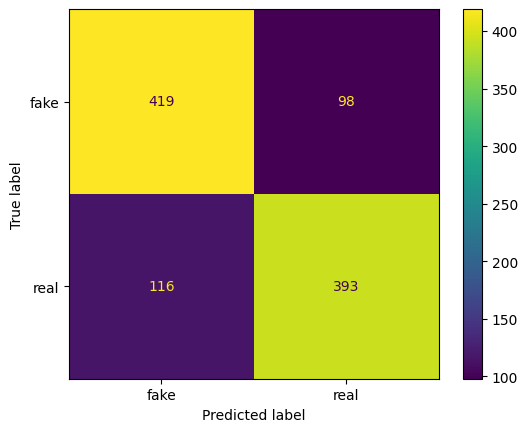

In [19]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# === 1. Khởi tạo mô hình SVM với kernel RBF (chuẩn nhất cho dữ liệu không tuyến tính)
svm_model = SVC(kernel='rbf', C=1, gamma='scale')  # Bạn có thể điều chỉnh C và gamma

# === 2. Train mô hình
svm_model.fit(Xh_train, yh_train)

# === 3. Dự đoán
y_pred = svm_model.predict(Xh_test)

# === 4. Đánh giá mô hình
print("🎯 Classification Report:")
print(classification_report(yh_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()


## gridsearch để tìm C tối ưu

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# === 1. Tạo lưới giá trị cho C để thử nghiệm ===
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],   # Bạn có thể mở rộng thêm nếu cần
    'gamma': ['scale'],            # Giữ nguyên gamma nếu chưa cần tối ưu
    'kernel': ['rbf']              # Dùng kernel RBF (phù hợp với dữ liệu ảnh đã PCA)
}

# === 2. Khởi tạo GridSearchCV ===
grid = GridSearchCV(
    SVC(), 
    param_grid, 
    cv=5,             # 5-fold cross-validation
    verbose=2,        # Hiển thị tiến trình
    n_jobs=-1         # Dùng tất cả CPU lõi có thể
)

# === 3. Huấn luyện mô hình và tìm C tối ưu ===
grid.fit(Xh_train, yh_train)

# === 4. In ra kết quả tốt nhất ===
print("🔥 Best parameters:", grid.best_params_)

# === 5. Dự đoán và đánh giá trên tập test ===
best_svm = grid.best_estimator_
y_pred = best_svm.predict(Xh_test)

print("\n🎯 Classification Report:")
print(classification_report(yh_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()


In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

## Random Forest - RandomizedSearchCV

In [ ]:
param_dist = {'n_estimators': np.arange(50,201,5),'max_depth': np.arange(20,201,5)}
rf = RandomForestClassifier()
rand_search = RandomizedSearchCV(rf, param_distributions = param_dist, n_iter=5, cv=5)
rand_search.fit(Xh_train, yh_train)
# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best Hyperparameters:',  rand_search.best_params_)

y_pred = best_rf.predict(Xh_test)

print(classification_report(yh_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(yh_test,y_pred),display_labels=['fake','real']).plot();

## Random Forest - GridSearchCV

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Định nghĩa grid các siêu tham số để thử nghiệm
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [20, 50, 100, 150]
}

# Tạo mô hình
rf = RandomForestClassifier(random_state=42)

# Grid Search với 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(Xh_train, yh_train)

# Lấy model tốt nhất
best_rf = grid_search.best_estimator_
print("✅ Best Hyperparameters:", grid_search.best_params_)

# Dự đoán và đánh giá
y_pred = best_rf.predict(Xh_test)
print(classification_report(yh_test, y_pred, target_names=['fake', 'real']))
ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake','real']).plot()
plt.title("Confusion Matrix - Best Random Forest")
plt.show()


## Decision Tree - Bagging

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# === 1. Tạo cây quyết định cơ bản ===
base_tree = DecisionTreeClassifier(random_state=42)

# === 2. Gói nhiều cây với BaggingClassifier ===
bagging_model = BaggingClassifier(
    base_estimator=base_tree,
    n_estimators=50,       # số lượng cây trong tập
    max_samples=0.8,       # tỷ lệ mẫu ngẫu nhiên mỗi cây (80% train)
    max_features=1.0,      # dùng toàn bộ đặc trưng
    bootstrap=True,        # lấy mẫu với thay thế (bootstrap sampling)
    n_jobs=-1,             # dùng tất cả CPU
    random_state=42
)

# === 3. Train mô hình ===
bagging_model.fit(Xh_train, yh_train)

# === 4. Dự đoán ===
y_pred = bagging_model.predict(Xh_test)

# === 5. Đánh giá kết quả ===
print("🎯 Classification Report (Bagging):")
print(classification_report(yh_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()


## Gradient Boosting

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# === 1. Khởi tạo mô hình boosting chạy đa luồng ===
gb_model = HistGradientBoostingClassifier(
    max_iter=150,        # số vòng lặp (tương đương n_estimators)
    learning_rate=0.3,
    max_depth=3,
    random_state=42,           # xem tiến trình huấn luyện
)

# === 2. Train model ===
gb_model.fit(Xh_train, yh_train)

# === 3. Dự đoán ===
y_pred = gb_model.predict(Xh_test)

# === 4. Đánh giá ===
print("🎯 Classification Report (HistGradientBoosting):")
print(classification_report(yh_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()


## Gradient Boosting - GridSearch find lr

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# === 1. Tạo lưới tham số cần tìm ===
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
    'max_iter': [50,100,150,200],         # giữ cố định hoặc có thể test thêm
    'max_depth': [3,5,7,9]           # bạn có thể mở rộng nếu muốn
}

# === 2. Khởi tạo model và GridSearchCV ===
model = HistGradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1
)

# === 3. Huấn luyện với tìm kiếm learning_rate ===
grid_search.fit(Xh_train, yh_train)

# === 4. Mô hình tốt nhất ===
best_model = grid_search.best_estimator_
print("🔥 Best params:", grid_search.best_params_)

# === 5. Dự đoán và đánh giá ===
y_pred = best_model.predict(Xh_test)

print("\n🎯 Classification Report (Best HistGBC):")
print(classification_report(yh_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()


Best params: {'learning_rate': 0.2, 'max_depth': 7, 'max_iter': 200}

## XGBClassifier

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# === 1. Khởi tạo mô hình XGBoost với các tham số cụ thể ===
xgb = XGBClassifier(
    n_estimators=100,         # Số cây (bạn có thể tinh chỉnh)
    max_depth=6,              # Độ sâu của cây
    learning_rate=0.1,        # Tốc độ học
    subsample=0.8,            # Tỷ lệ mẫu mỗi cây
    colsample_bytree=0.8,     # Tỷ lệ cột mỗi cây
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# === 2. Fit mô hình lên tập huấn luyện ===
xgb.fit(Xh_train, yh_train)

# === 3. Dự đoán trên tập test ===
y_pred = xgb.predict(Xh_test)

# === 4. Đánh giá mô hình ===
print("\n🎯 Classification Report:")
print(classification_report(yh_test, y_pred))

# === 5. Ma trận nhầm lẫn (Confusion Matrix) ===
ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()


In [ ]:
# Gộp lại PCA features với nhãn
features_pca['label'] = y.values  # thêm cột label vào cuối

# Lưu ra file CSV chứa feature và labels
features_pca.to_csv('/kaggle/working/features_handcraft_0.76.csv', index=False)
